In [46]:
# conda install pmdarima
# make it silent. don't ask for user input
# !conda install -y -q pmdarima

In [47]:
import numpy as np
import pandas as pd
import pmdarima as pm
from pmdarima.model_selection import train_test_split

# Generate dummy data with trend, seasonality, and exogenous variables
np.random.seed(123)
n_samples = 100
time_index = pd.date_range(start='2022-01-01', periods=n_samples, freq='M')

# Generate trend
trend = np.linspace(0, 2, n_samples)

# Generate seasonality
seasonality = np.sin(np.arange(n_samples) * (2 * np.pi / 12)) * 3

# Generate exogenous variables
exog1 = np.random.normal(0, 1, n_samples)
exog2 = np.random.normal(0, 1, n_samples)

# Combine components to create dummy time series data
data = trend + seasonality + exog1 * 2 + exog2 * 1.5 + np.random.normal(0, 1, n_samples)

# Create a DataFrame
df = pd.DataFrame({'timestamp': time_index, 'value': data, 'exog1': exog1, 'exog2': exog2})
df = df.set_index('timestamp')

print(df)

# Split data into train and test sets
train_data, test_data = train_test_split(df, train_size=0.8)

# Fit auto_arima model with exogenous variables
model = pm.auto_arima(train_data['value'], exogenous=train_data[['exog1', 'exog2']], 
                      seasonal=True, m=12, suppress_warnings=True, trace=True)

# Make predictions on test set
exog_forecast = test_data[['exog1', 'exog2']]
predictions = model.predict(n_periods=len(test_data), exogenous=exog_forecast)

# Print model summary and predictions
print(model.summary())
print("Predictions:")
print(predictions)

/var/folders/x_/rd78sz7s181dgnvygzmgz0b40000gn/T/ipykernel_45779/577382780.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_index = pd.date_range(start='2022-01-01', periods=n_samples, freq='M')


               value     exog1     exog2
timestamp                               
2022-01-31 -0.504869 -1.085631  0.642055
2022-02-28 -0.050044  0.997345 -1.977888
2022-03-31  6.473536  0.282978  0.712265
2022-04-30  4.633769 -1.506295  2.598304
2022-05-31  1.478438 -0.578600 -0.024626
...              ...       ...       ...
2029-12-31 -1.669374  1.031114 -3.231055
2030-01-31  1.242118 -1.084568 -0.269293
2030-02-28  0.982071 -1.363472 -0.110851
2030-03-31  4.985327  0.379401 -0.341262
2030-04-30  4.734488 -0.379176 -0.217946

[100 rows x 3 columns]
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=418.118, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=433.985, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=419.720, Time=0.03 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=420.915, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=437.711, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=416.227, Time=0.15 sec
 ARI

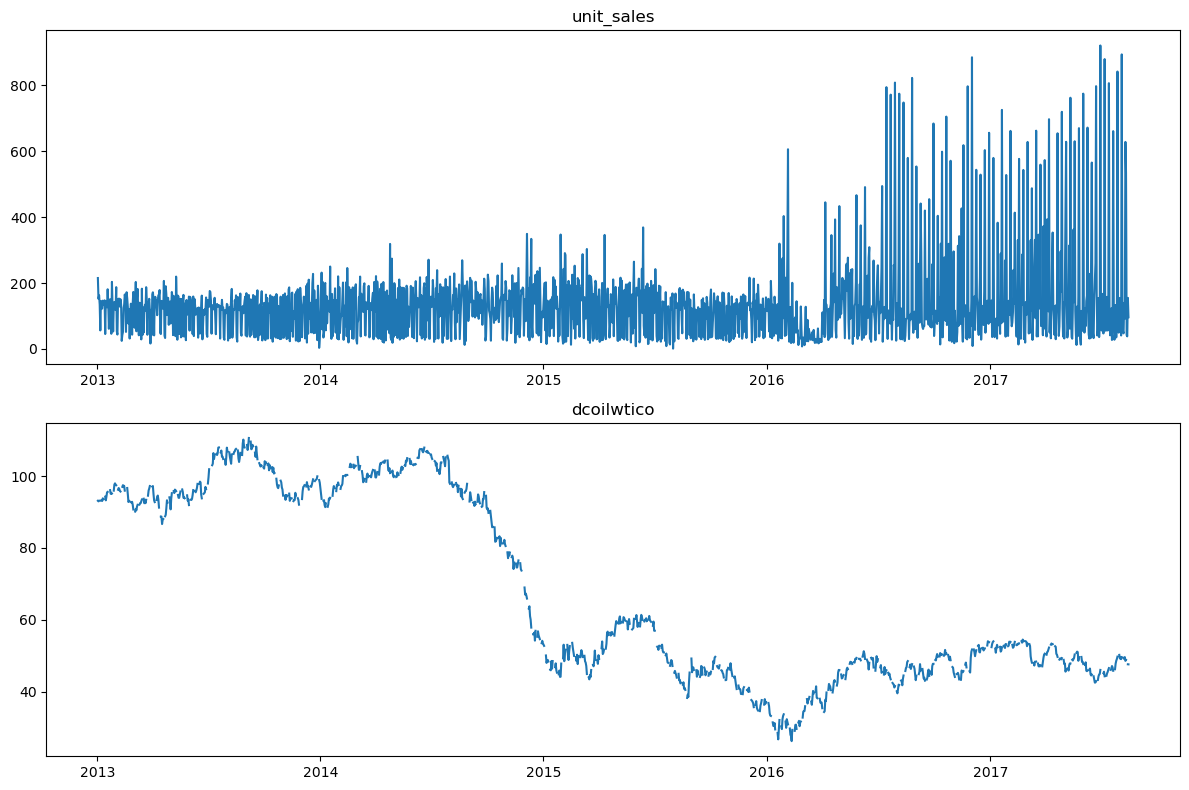

In [48]:
filename = 'data_yes_promo_no_oil_no_ma.json'
import pandas
import json
with open(filename) as f:
    data = json.load(f)
    fulldf = pandas.DataFrame(data)


# drop any row with date in the month 2016-04 - 2016-05
# fulldf = fulldf[~fulldf['date'].str.contains('2016-04')]

fulldf['unit_sales'] = fulldf['unit_sales'].astype(float)
fulldf['dcoilwtico'] = fulldf['dcoilwtico'].astype(float)
fulldf['onpromotionnum'] = fulldf['onpromotionnum'].astype(float)
fulldf['negative_sales'] = fulldf['negative_sales'].astype(float)
fulldf['date'] = pd.to_datetime(fulldf['date'])
# fulldf = fulldf.set_index('date')
    
# plot both unit_sales and dcoilwtico
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
ax[0].plot(fulldf['date'], fulldf['unit_sales'], label='unit_sales')
ax[0].set_title('unit_sales')
ax[1].plot(fulldf['date'], fulldf['dcoilwtico'], label='dcoilwtico')
ax[1].set_title('dcoilwtico')
plt.tight_layout()
plt.show()

In [49]:
fulldf

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,perishable,city,...,locale_name,description,transferred,holiday_type,transactions,onpromotionnum,negative_sales,unit_sales_ma7,unit_sales_ma15,unit_sales_ma31
0,2122,2013-01-02,2,582864,215.144,None,MEATS,2302,1,Quito,...,None,None,None,None,2358,NaN,0.0,9.6773333333333333,31.003999999999998,53.467333333333336
1,43721,2013-01-03,2,582864,152.054,None,MEATS,2302,1,Quito,...,None,None,None,None,2033,NaN,0.0,7.0,3.5714285714285716,2.2
2,83803,2013-01-04,2,582864,162.482,None,MEATS,2302,1,Quito,...,None,None,None,None,2066,NaN,0.0,13.307166666666667,6.2745,3.4614333333333334
3,123928,2013-01-05,2,582864,134.204,None,MEATS,2302,1,Quito,...,Ecuador,Recupero puente Navidad,false,Work Day,2062,NaN,0.0,2.5,2.2142857142857144,2.1
4,166123,2013-01-06,2,582864,56.251,None,MEATS,2302,1,Quito,...,None,None,None,None,1992,NaN,0.0,87.275333333333336,58.11121428571429,60.718566666666668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,124977476,2017-08-11,2,582864,533.217,True,MEATS,2302,1,Quito,...,Ecuador,Traslado Primer Grito de Independencia,false,Transfer,1698,1.0,0.0,13.897333333333334,6.5274285714285716,3.5794666666666668
1705,125082447,2017-08-12,2,582864,42.303,False,MEATS,2302,1,Quito,...,None,None,None,None,1613,0.0,0.0,28.0605,12.597357142857144,6.4121
1706,125187130,2017-08-13,2,582864,38.217,False,MEATS,2302,1,Quito,...,None,None,None,None,1658,0.0,0.0,8.3236666666666661,4.1387142857142853,2.4647333333333332
1707,125293951,2017-08-14,2,582864,154.944,False,MEATS,2302,1,Quito,...,None,None,None,None,1788,0.0,0.0,10.7895,5.1955,2.9579


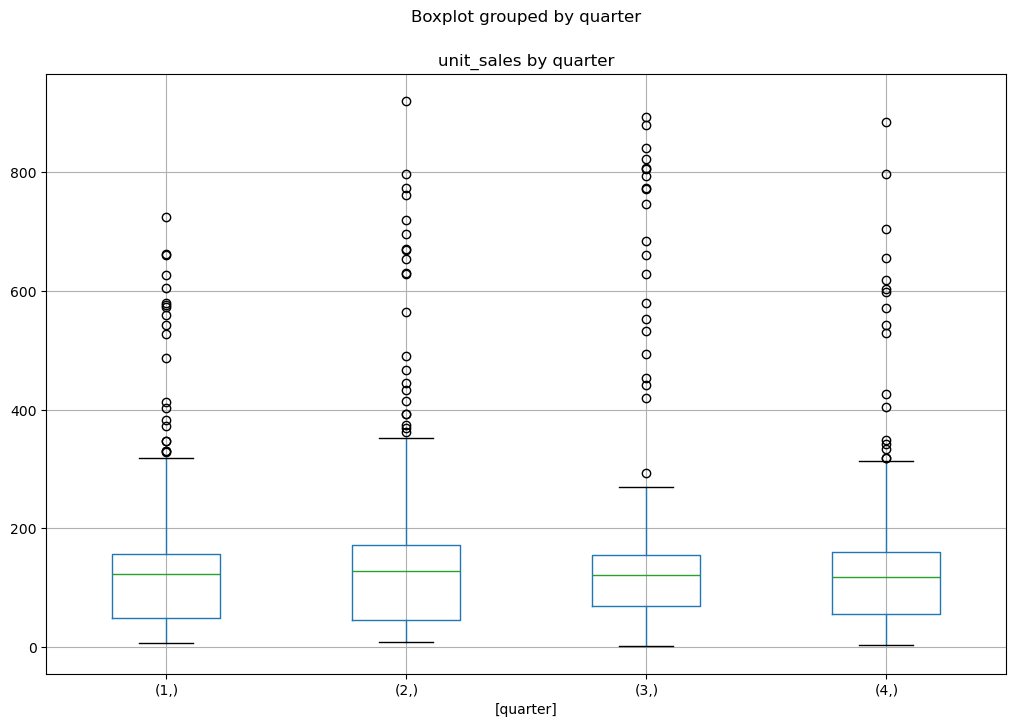

In [50]:
# from the fulldf, group by quarter and plot the box plot distribution of unit_sales
fulldf['quarter'] = fulldf['date'].dt.quarter
fulldf['year'] = fulldf['date'].dt.year

fig, ax = plt.subplots(figsize=(12, 8))
fulldf.boxplot(column='unit_sales', by=['quarter'], ax=ax)
plt.title('unit_sales by quarter')
plt.show()


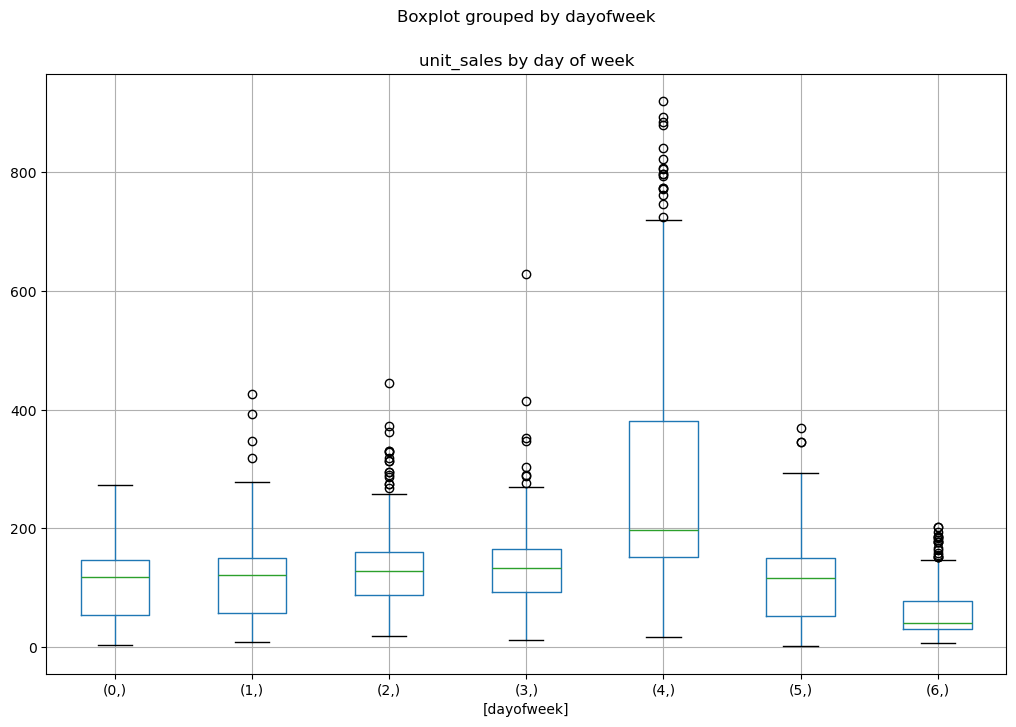

In [51]:
# boxplot of unit_sales by day of week
fulldf['dayofweek'] = fulldf['date'].dt.dayofweek
fig, ax = plt.subplots(figsize=(12, 8))
fulldf.boxplot(column='unit_sales', by=['dayofweek'], ax=ax)
plt.title('unit_sales by day of week')
plt.show()


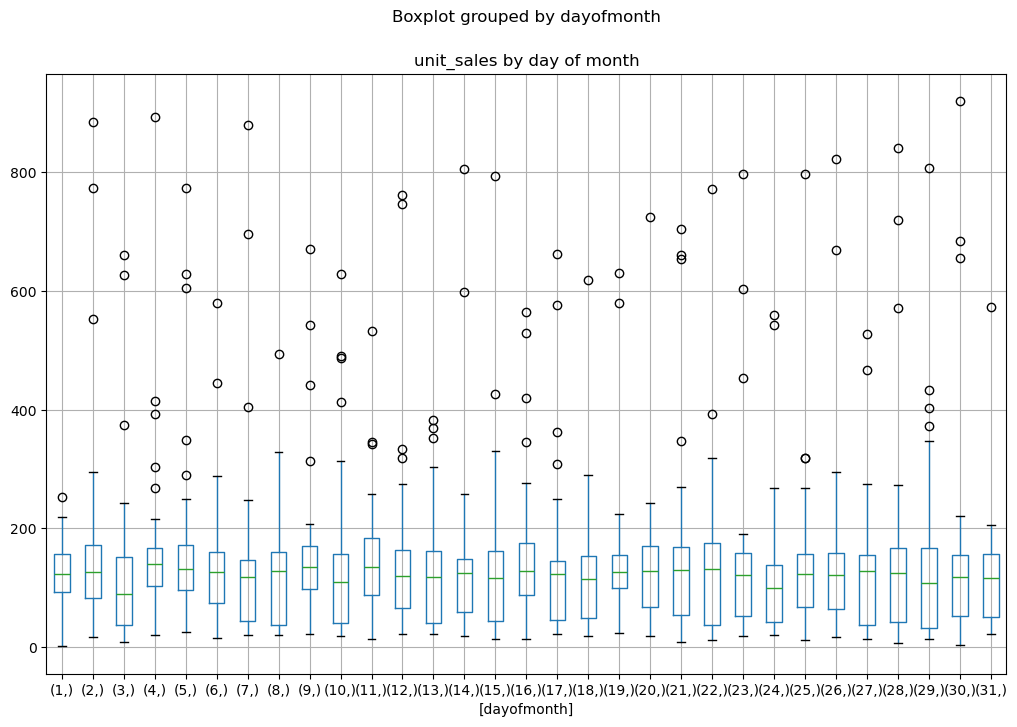

In [52]:
# boxplot of unit_sales by day of month
fulldf['dayofmonth'] = fulldf['date'].dt.day
fig, ax = plt.subplots(figsize=(12, 8))
fulldf.boxplot(column='unit_sales', by=['dayofmonth'], ax=ax)
plt.title('unit_sales by day of month')
plt.show()


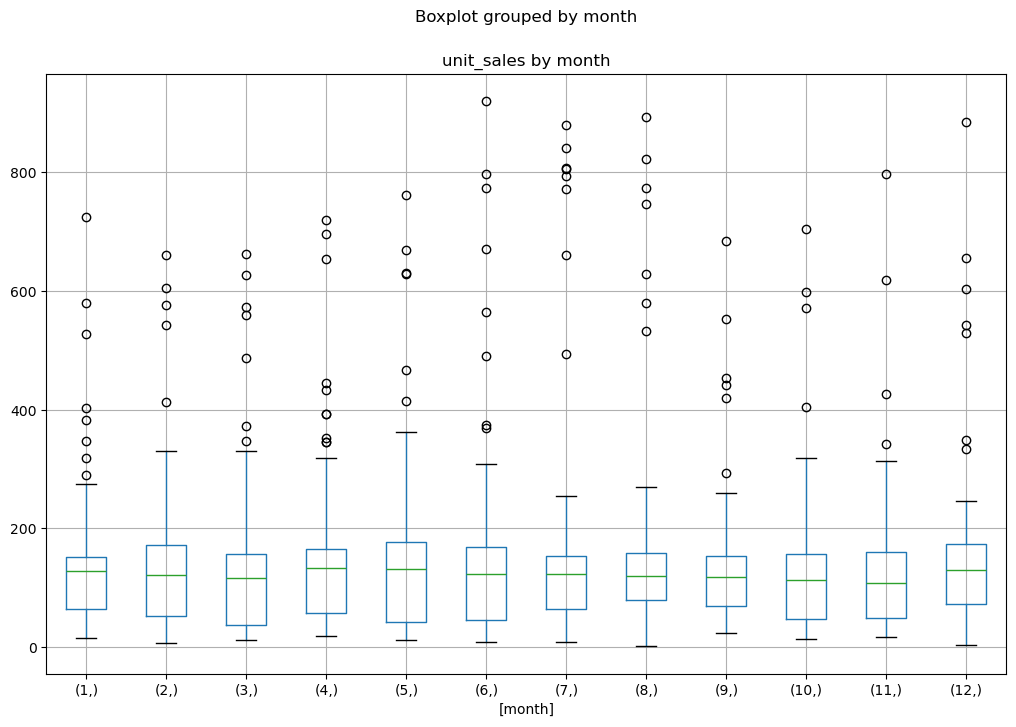

In [53]:
# boxplot by month
fulldf['month'] = fulldf['date'].dt.month
fig, ax = plt.subplots(figsize=(12, 8))
fulldf.boxplot(column='unit_sales', by=['month'], ax=ax)
plt.title('unit_sales by month')
plt.show()

In [54]:
# filename = 'bquxjob_61c56e44_18ff212b50b.json'
import pandas
import json
with open(filename) as f:
    data = json.load(f)
    fulldf = pandas.DataFrame(data)


# move average of 7 days of unit_sales, not including the current day
fulldf['unit_sales_7d'] = fulldf['unit_sales'].rolling(window=7).mean()
fulldf['unit_sales_14d'] = fulldf['unit_sales'].rolling(window=14).mean()
fulldf['unit_sales_28d'] = fulldf['unit_sales'].rolling(window=28).mean()


# drop any row with date in the month 2016-04 - 2016-05
if False:
    fulldf = fulldf[~fulldf['date'].str.contains('2016-04')]

fulldf['unit_sales'] = fulldf['unit_sales'].astype(float)
fulldf['dcoilwtico'] = fulldf['dcoilwtico'].astype(float)
fulldf['onpromotionnum'] = fulldf['onpromotionnum'].astype(float)
fulldf['negative_sales'] = fulldf['negative_sales'].astype(float)
fulldf['date'] = pd.to_datetime(fulldf['date'])
# fulldf = fulldf.set_index('date')

# create 4 new columns for quarter is_q1, is_q2, is_q3, is_q4. 1 and 0. not boolean
for i in range(1, 5):
    fulldf[f'is_q{i}'] = (fulldf['date'].dt.quarter == i).astype(float)

# create 12 columns for month, is_m1, is_m2, ... is_m12. 1 and 0. not boolean
for i in range(1, 13):
    fulldf[f'is_m{i}'] = (fulldf['date'].dt.month == i).astype(float)

# create 31 columns for day of month, is_d1, is_d2, ... is_d31. 1 and 0. not boolean
for i in range(1, 32):
    fulldf[f'is_d{i}'] = (fulldf['date'].dt.day == i).astype(float)

# create 7 columns for day of week, is_dow0, is_dow1, ... is_dow6. 1 and 0. not boolean
for i in range(7):
    fulldf[f'is_dow{i}'] = (fulldf['date'].dt.dayofweek == i).astype(float)
    
fulldf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1709 entries, 0 to 1708
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1709 non-null   object        
 1   date             1709 non-null   datetime64[ns]
 2   store_nbr        1709 non-null   object        
 3   item_nbr         1709 non-null   object        
 4   unit_sales       1709 non-null   float64       
 5   onpromotion      1252 non-null   object        
 6   family           1709 non-null   object        
 7   class            1709 non-null   object        
 8   perishable       1709 non-null   object        
 9   city             1709 non-null   object        
 10  state            1709 non-null   object        
 11  cluster          1709 non-null   object        
 12  store_type       1709 non-null   object        
 13  dcoilwtico       1178 non-null   float64       
 14  locale           277 non-null    object 

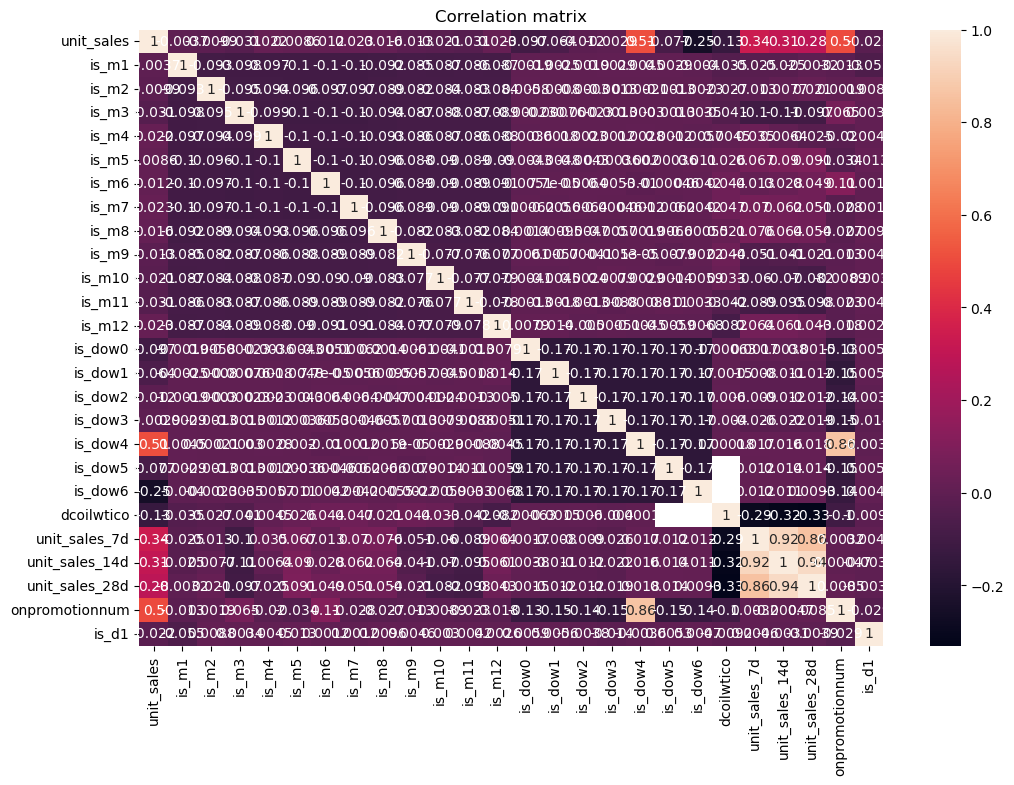

In [55]:
factor_columns = [
    'is_m1',
    'is_m2',
    'is_m3',
    'is_m4',
    'is_m5',
    'is_m6',
    'is_m7',
    'is_m8',
    'is_m9',
    'is_m10',
    'is_m11',
    'is_m12',
    'is_dow0',
    'is_dow1',
    'is_dow2',
    'is_dow3',
    'is_dow4',
    'is_dow5',
    'is_dow6',
    'dcoilwtico',
    'unit_sales_7d',
    'unit_sales_14d',
    'unit_sales_28d',
    'onpromotionnum',
    'is_d1'
]

# show cross correlation matrix between unit_sales and other columns
corr = fulldf[['unit_sales'] + factor_columns].corr()
corr

# plot the correlation matrix
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, ax=ax)
plt.title('Correlation matrix')
plt.show()


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.17 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=17008.740, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=16218.004, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=17006.741, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=16657.603, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=16160.767, Time=0.48 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=16160.743, Time=1.62 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=16159.680, Time=0.36 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=16383.792, Time=0.17 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=16160.561, Time=0.80 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=16257.637, Time=0.47 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=16698.877, Time=0.23 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   :

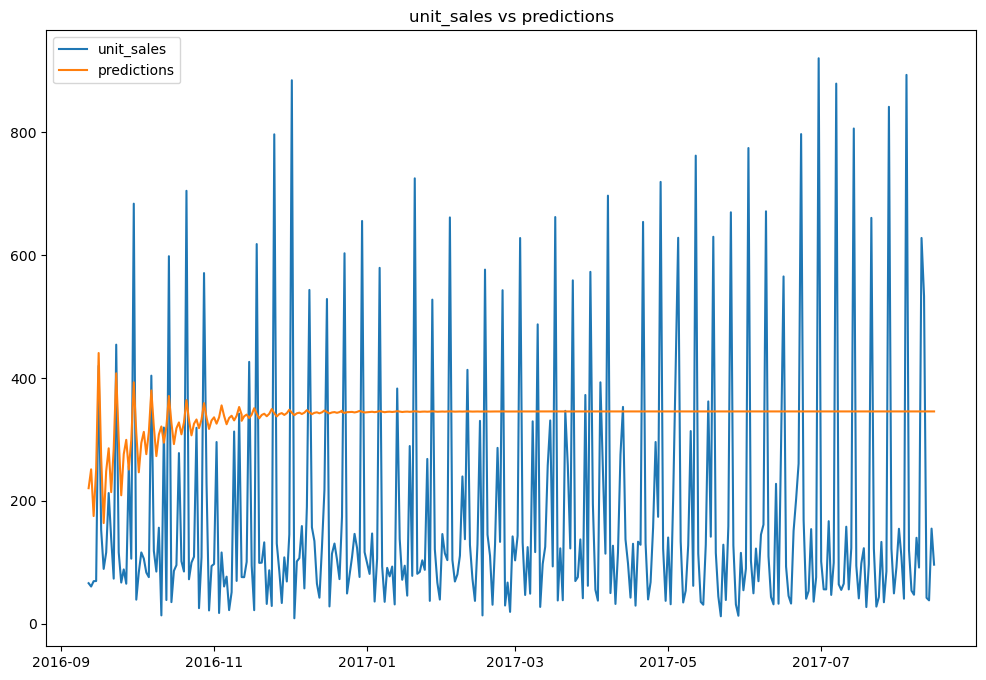

RMSE: 252.21495123637933


In [56]:
# use pmdarima to predict unit_sales
import numpy as np
import pandas as pd
import pmdarima as pm
from pmdarima.model_selection import train_test_split

# Split data into train and test sets
train_data, test_data = train_test_split(fulldf, train_size=0.8)

exo_columns = ['is_q1', 'is_m5']

# Fit auto_arima model with exogenous variables
model = pm.auto_arima(
    train_data['unit_sales'],
    exogenous=train_data[exo_columns], 
    seasonal=True,
    m=7,
    suppress_warnings=True,
    trace=True
)

# Make predictions on test set
exog_forecast = test_data[exo_columns]
predictions = model.predict(n_periods=len(test_data), exogenous=exog_forecast)

# Print model summary and predictions
print(model.summary())
print("Predictions:")
print(predictions)

# plot the predictions
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(test_data['date'], test_data['unit_sales'], label='unit_sales')
ax.plot(test_data['date'], predictions, label='predictions')
plt.legend()
plt.title('unit_sales vs predictions')
plt.show()

# print RMSE
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(test_data['unit_sales'], predictions))
print(f'RMSE: {rmse}')

In [57]:
test_data['unit_sales'].std()

201.77697377127305

RMSE: 141.27867248287612


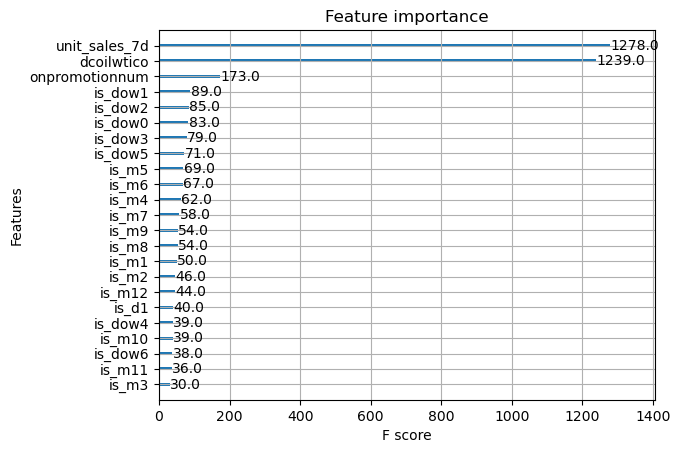

In [58]:
# just use xgb to predict unit_sales using only is_q1 is_q2 is_q3 is_q4
# print rmse in the end
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

factor_columns = [
    # 'is_q1',
    # 'is_q2',
    # 'is_q3',
    # 'is_q4',
    'dcoilwtico',
    'onpromotionnum',
    'unit_sales_7d',
    # 'unit_sales_14d',
    # 'unit_sales_28d',
    'is_m1',
    'is_m2',
    'is_m3',
    'is_m4',
    'is_m5',
    'is_m6',
    'is_m7',
    'is_m8',
    'is_m9',
    'is_m10',
    'is_m11',
    'is_m12',

    'is_d1',

    'is_dow0',
    'is_dow1',
    'is_dow2',
    'is_dow3',
    'is_dow4',
    'is_dow5',
    'is_dow6',
]

# X = fulldf[factor_columns]
# y = fulldf['unit_sales']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

X_train = train_data[factor_columns]
y_train = train_data['unit_sales']
X_test = test_data[factor_columns]
y_test = test_data['unit_sales']

xgbmodel = XGBRegressor()
xgbmodel.fit(X_train, y_train)

y_pred = xgbmodel.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('RMSE:', rmse)

# plot the feature importance
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgbmodel)
plt.show()


RMSE 141.27867248287612


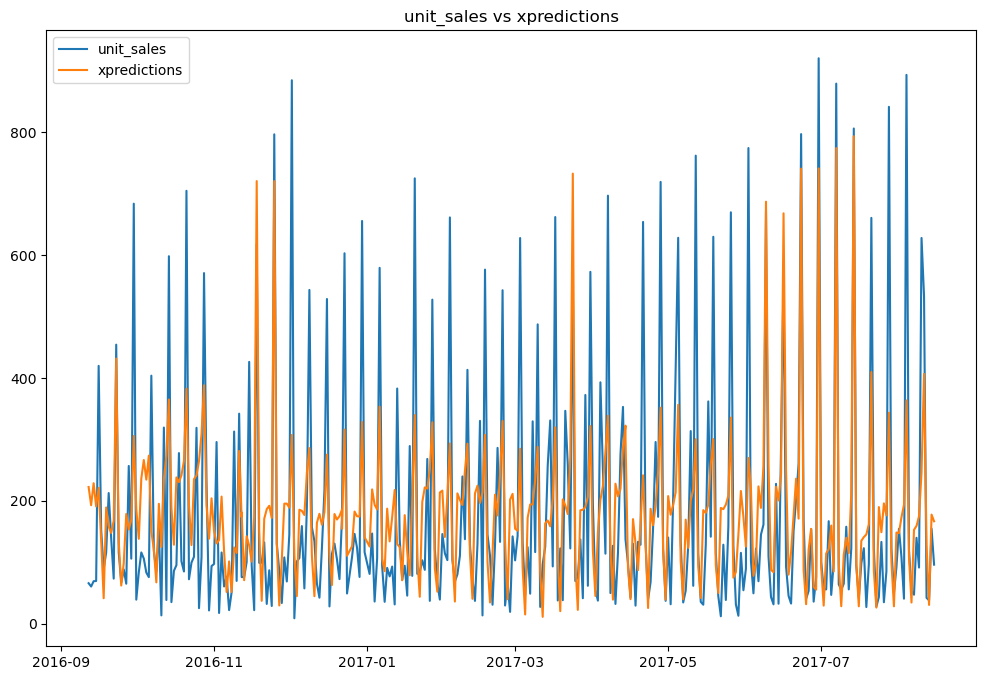

In [59]:
# factor_columns = ['is_q1', 'dcoilwtico', ]

xprediction = xgbmodel.predict(test_data[factor_columns].to_numpy())

# calculate rmse
print('RMSE', np.sqrt(mean_squared_error(test_data['unit_sales'], xprediction)))

# plot the xpredictions
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(test_data['date'], test_data['unit_sales'], label='unit_sales')
ax.plot(test_data['date'], xprediction, label='xpredictions')
plt.legend()
plt.title('unit_sales vs xpredictions')
plt.show()


In [60]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

# TimeSeries Cross-validation
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'colsample_bytree': [0.5, 0.8, 1],
    'gamma': [0, 1, 5, 10, 100, 1000],
    'reg_alpha': [0, 1, 5],
    'reg_lambda': [0, 1, 5],
}

grid_search = GridSearchCV(
    XGBRegressor(),
    param_grid,
    cv=tscv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best score:', grid_search.best_score_)
print('RMSE:', np.sqrt(mean_squared_error(y_test, grid_search.predict(X_test))))

Best parameters: {'colsample_bytree': 1, 'gamma': 1000, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 5, 'reg_lambda': 5}
Best score: 0.28070616522868963
RMSE: 112.07223906769109


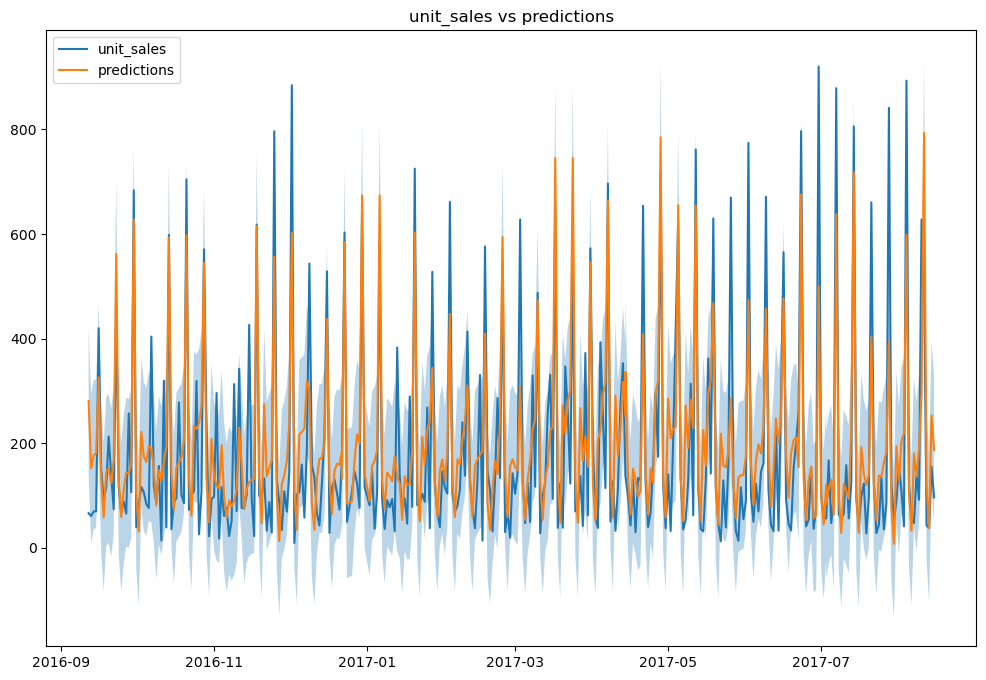

RMSE 112.07223906769109


In [61]:
# factor_columns = ['is_q1', 'dcoilwtico', ]

xprediction = grid_search.predict(test_data[factor_columns].to_numpy())

# predict the confidence interval. note grid_search is xgboost model
from scipy.stats import norm

# calculate the standard deviation of the residuals
residuals = y_test - grid_search.predict(X_test)
std_residuals = residuals.std()

# calculate the confidence interval
confidence = 0.80
z = norm.ppf(1 - (1 - confidence) / 2)
interval = z * std_residuals

# calculate the lower and upper bound
lower_bound = xprediction - interval
upper_bound = xprediction + interval

# plot the predictions
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(test_data['date'], test_data['unit_sales'], label='unit_sales')
ax.plot(test_data['date'], xprediction, label='predictions')
ax.fill_between(test_data['date'], lower_bound, upper_bound, alpha=0.3)
plt.legend()
plt.title('unit_sales vs predictions')
plt.show()

# calculate rmse
print('RMSE', np.sqrt(mean_squared_error(test_data['unit_sales'], xprediction)))

# # plot the xpredictions
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.plot(test_data['date'], test_data['unit_sales'], label='unit_sales')
# ax.plot(test_data['date'], xprediction, label='xpredictions')
# plt.legend()
# plt.title('unit_sales vs xpredictions')
# plt.show()


In [62]:
# conda install prophet
# !conda install -y -q -c conda-forge fbprophet

In [63]:
# # use facebook's prophet to forecast
# # use the new version, not the old fbprophet
# from prophet import Prophet

# # Create a DataFrame
# df = fulldf.copy()
# df = df.set_index('date')

# # Split data into train and test sets
# train_data, test_data = train_test_split(df, train_size=0.9)

# # Prophet requires the date column to be named 'ds' and the value column to be named 'y'
# train_data = train_data.rename(columns={'unit_sales': 'y'})
# train_data = train_data.reset_index()
# train_data = train_data.rename(columns={'date': 'ds'})

# # Fit Prophet model
# model = Prophet()
# model.fit(train_data)

# # Make predictions on test set
# future = model.make_future_dataframe(periods=len(test_data))
# forecast = model.predict(future)

# # Print model summary and predictions
# # print(model.summary())
# # print("Predictions:")
# # print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])
# rmse = sqrt(mean_squared_error(test_data['unit_sales'], forecast['yhat'][-len(test_data):]))
# print('validation RMSE', rmse)
# print('stdev of test data', test_data['unit_sales'].std())

